# 06 Final Analysis: Confusion Structure, EEG Signal Contrast, and Fragment-SVM Reverse Identification

This notebook is designed as the final extension after `01`-`05`. It responds directly to the remaining critique that the model result should be interpreted more deeply, rather than only reported as a single accuracy number.

We add three final analyses:

1. **Confusion-matrix diagnosis**: identify which subjects are easiest, which subjects are confused, and whether errors are symmetric.
2. **EEG signal comparison**: compare subject-level ERP waveforms for the easiest and most confused pairs, especially in posterior visual electrodes.
3. **Reverse identification with fragmented signals**: randomly crop short EEG fragments and test whether an SVM can still infer the subject identity.

The logic is: if short, randomly sampled EEG fragments still classify above chance, then the neural fingerprint is not only a full-epoch artifact. It is distributed across local time-frequency structure.

## Current Project State Before 06

The previous notebooks established the following chain of evidence:

$$
\text{Raw EEG} \rightarrow \text{preprocessed epochs} \rightarrow \text{PSD baseline} \rightarrow \text{DWT features} \rightarrow \text{biometric classification}.
$$

Main known results from `05_ml.ipynb`:

- PSD + Logistic Regression baseline: approximately **80.83%**.
- DWT + Logistic Regression: **89.12%**.
- DWT + RBF-SVM: **82.05%**.
- DWT + Random Forest: **72.02%**.
- Averaged / phase-cancelled DWT condition: **94.97%** with LR.
- Animals and objects semantic subsets stay close to baseline: **89.20%** and **88.92%**.
- Random pooled condition rises to **98.70%**; chronological pooled split remains strong at **96.03%**.

Interpretation so far: the identity signal is concentrated in posterior visual channels and mid-scale wavelet bands, especially through `log_energy`, `mean`, and `std`. The unresolved question is how this identity signal behaves at the level of specific confusions and short fragments.

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
SUBJECT_LABELS = [f"sub-{i:02d}" for i in range(1, 11)]
FEATURE_PATH = "wavelet_outputs/all_subjects_wavelet_features_db4_L5.npz"
RAW_8CH_DIR = "data/my_preprocessed_data_8ch"
FS = 500.0
CHANCE_LEVEL = 1 / len(SUBJECT_LABELS)

print("Ready. Chance level:", f"{CHANCE_LEVEL:.2%}")

Ready. Chance level: 10.00%


## 1. Detailed Confusion-Matrix Diagnosis

The baseline accuracy from `05` is already high, but the confusion matrix tells us where the model fails. We compute:

- per-subject recall from the normalized confusion-matrix diagonal;
- the strongest off-diagonal confusion pairs;
- asymmetric error directions, e.g. whether `sub-03 -> sub-07` occurs more than `sub-07 -> sub-03`;
- classification report precision/recall/F1.

This converts the confusion matrix from a visual check into a quantitative diagnostic table.

In [2]:
data = np.load(FEATURE_PATH, allow_pickle=True)
X = data["X_features"]
y = data["y_labels"]
layout = data["layout"]

print("Feature matrix:", X.shape)
print("Labels:", y.shape)
print("Class counts:", np.bincount(y))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, n_jobs=-1),
)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred)

print(f"Baseline DWT + LR accuracy: {acc_lr:.4f} ({acc_lr * 100:.2f}%)")

Feature matrix: (20000, 240)
Labels: (20000,)
Class counts: [2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]
Baseline DWT + LR accuracy: 0.8912 (89.12%)


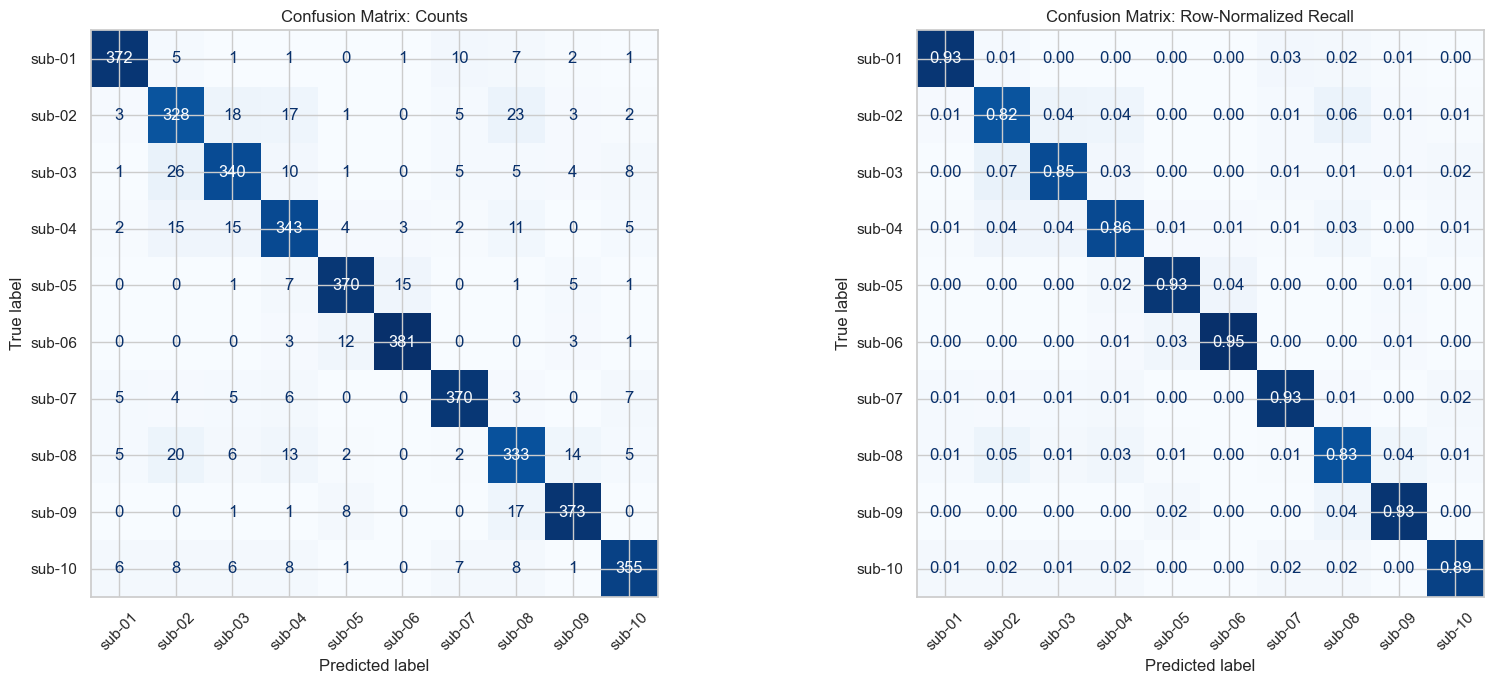

,precision,recall,f1-score,support
sub-02,0.807882,0.8200,0.813896,400
sub-08,0.816176,0.8325,0.824257,400
sub-03,0.865140,0.8500,0.857503,400
sub-04,0.838631,0.8575,0.847960,400
sub-10,0.922078,0.8875,0.904459,400
sub-07,0.922693,0.9250,0.923845,400
sub-05,0.927318,0.9250,0.926158,400
sub-01,0.944162,0.9300,0.937028,400
sub-09,0.920988,0.9325,0.926708,400
sub-06,0.952500,0.9525,0.952500,400


In [3]:
cm_counts = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

ConfusionMatrixDisplay(cm_counts, display_labels=SUBJECT_LABELS).plot(
    ax=axes[0], cmap="Blues", values_format="d", colorbar=False
)
axes[0].set_title("Confusion Matrix: Counts")
axes[0].tick_params(axis="x", rotation=45)

ConfusionMatrixDisplay(cm_norm, display_labels=SUBJECT_LABELS).plot(
    ax=axes[1], cmap="Blues", values_format=".2f", colorbar=False
)
axes[1].set_title("Confusion Matrix: Row-Normalized Recall")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

report = classification_report(
    y_test,
    y_pred,
    target_names=SUBJECT_LABELS,
    output_dict=True,
)

report_df = (
    pd.DataFrame(report)
    .T
    .loc[SUBJECT_LABELS, ["precision", "recall", "f1-score", "support"]]
)
report_df["support"] = report_df["support"].astype(int)
display(report_df.sort_values("recall"))

In [4]:
def strongest_confusions(cm, labels):
    rows = []
    for true_i in range(cm.shape[0]):
        for pred_j in range(cm.shape[1]):
            if true_i == pred_j:
                continue
            rows.append({
                "true_subject": labels[true_i],
                "predicted_subject": labels[pred_j],
                "count": int(cm[true_i, pred_j]),
                "row_error_rate": cm[true_i, pred_j] / cm[true_i].sum(),
            })
    return pd.DataFrame(rows).sort_values(["count", "row_error_rate"], ascending=False)

confusion_pairs = strongest_confusions(cm_counts, SUBJECT_LABELS)
display(confusion_pairs.head(15))

pair_rows = []
for i in range(len(SUBJECT_LABELS)):
    for j in range(i + 1, len(SUBJECT_LABELS)):
        pair_rows.append({
            "subject_a": SUBJECT_LABELS[i],
            "subject_b": SUBJECT_LABELS[j],
            "a_to_b": int(cm_counts[i, j]),
            "b_to_a": int(cm_counts[j, i]),
            "mutual_confusion": int(cm_counts[i, j] + cm_counts[j, i]),
            "asymmetry": int(abs(cm_counts[i, j] - cm_counts[j, i])),
        })

pair_df = pd.DataFrame(pair_rows).sort_values(
    ["mutual_confusion", "asymmetry"], ascending=False
)
display(pair_df.head(10))

easiest_subject = report_df["recall"].idxmax()
hardest_subject = report_df["recall"].idxmin()
top_pair = pair_df.iloc[0]

print("Easiest subject by recall:", easiest_subject, f"recall={report_df.loc[easiest_subject, 'recall']:.3f}")
print("Hardest subject by recall:", hardest_subject, f"recall={report_df.loc[hardest_subject, 'recall']:.3f}")
print("Most confused pair:", top_pair["subject_a"], "<->", top_pair["subject_b"], "mutual errors=", top_pair["mutual_confusion"])

,true_subject,predicted_subject,count,row_error_rate
19,sub-03,sub-02,26,0.0650
15,sub-02,sub-08,23,0.0575
64,sub-08,sub-02,20,0.0500
10,sub-02,sub-03,18,0.0450
11,sub-02,sub-04,17,0.0425
79,sub-09,sub-08,17,0.0425
28,sub-04,sub-02,15,0.0375
29,sub-04,sub-03,15,0.0375
40,sub-05,sub-06,15,0.0375
70,sub-08,sub-09,14,0.0350


,subject_a,subject_b,a_to_b,b_to_a,mutual_confusion,asymmetry
9,sub-02,sub-03,18,26,44,8
14,sub-02,sub-08,23,20,43,3
10,sub-02,sub-04,17,15,32,2
42,sub-08,sub-09,14,17,31,3
30,sub-05,sub-06,15,12,27,3
17,sub-03,sub-04,10,15,25,5
27,sub-04,sub-08,11,13,24,2
5,sub-01,sub-07,10,5,15,5
23,sub-03,sub-10,8,6,14,2
41,sub-07,sub-10,7,7,14,0


Easiest subject by recall: sub-06 recall=0.953
Hardest subject by recall: sub-02 recall=0.820
Most confused pair: sub-02 <-> sub-03 mutual errors= 44


## 2. EEG Signal Comparison Behind the Confusions

Next, we ask whether the strongest model confusions are visible in the EEG itself. We load the preprocessed 8-channel epochs and compare average ERP waveforms.

For each pair, the notebook computes:

$$
d_{\mathrm{RMS}}(a,b)=\sqrt{\frac{1}{CT}\sum_{c=1}^{C}\sum_{t=1}^{T}(ERP_{a,c,t}-ERP_{b,c,t})^2}
$$

and Pearson correlation between flattened ERP tensors. A confused pair should often show lower RMS distance and higher waveform similarity than an easy pair.

In [5]:
def load_subject_epochs(subject_label, base_dir=RAW_8CH_DIR, max_trials=3000, seed=RANDOM_STATE):
    path = os.path.join(base_dir, subject_label, "preprocessed_eeg_train.npz")
    data_raw = np.load(path, allow_pickle=True)
    epochs = data_raw["preprocessed_eeg_data"]
    ch_names = [str(x) for x in data_raw["ch_names"]]

    rng = np.random.default_rng(seed)
    if max_trials is not None and epochs.shape[0] > max_trials:
        idx = rng.choice(epochs.shape[0], size=max_trials, replace=False)
        epochs = epochs[idx]
    return epochs, ch_names

def erp_for_subject(subject_label, max_trials=3000):
    epochs, ch_names = load_subject_epochs(subject_label, max_trials=max_trials)
    return epochs.mean(axis=0), ch_names

def erp_similarity(subject_a, subject_b, max_trials=3000):
    erp_a, ch_names = erp_for_subject(subject_a, max_trials=max_trials)
    erp_b, _ = erp_for_subject(subject_b, max_trials=max_trials)
    diff = erp_a - erp_b
    rms = np.sqrt(np.mean(diff ** 2))
    corr = np.corrcoef(erp_a.ravel(), erp_b.ravel())[0, 1]
    return rms, corr, erp_a, erp_b, ch_names

most_confused_pair = (top_pair["subject_a"], top_pair["subject_b"])
easy_pair = (easiest_subject, hardest_subject)

pairs_to_plot = {
    "most_confused_pair": most_confused_pair,
    "contrast_pair_easiest_vs_hardest": easy_pair,
}

similarity_rows = []
erp_cache = {}
for pair_name, (a, b) in pairs_to_plot.items():
    rms, corr, erp_a, erp_b, ch_names = erp_similarity(a, b)
    erp_cache[pair_name] = (a, b, erp_a, erp_b, ch_names)
    similarity_rows.append({
        "pair_type": pair_name,
        "subject_a": a,
        "subject_b": b,
        "erp_rms_distance": rms,
        "erp_flattened_corr": corr,
    })

similarity_df = pd.DataFrame(similarity_rows)
display(similarity_df)

,pair_type,subject_a,subject_b,erp_rms_distance,erp_flattened_corr
0,most_confused_pair,sub-02,sub-03,0.000004,-0.218112
1,contrast_pair_easiest_vs_hardest,sub-06,sub-02,0.000001,0.385575


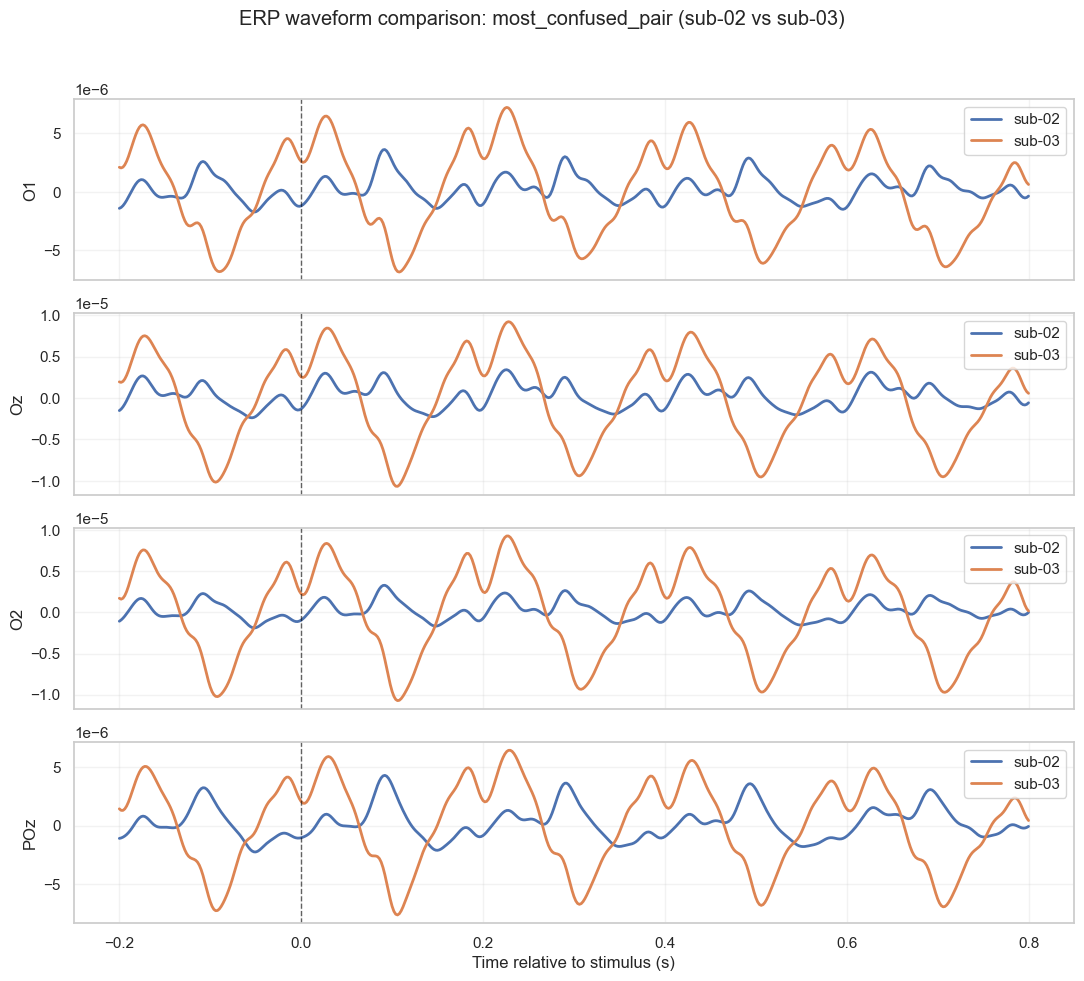

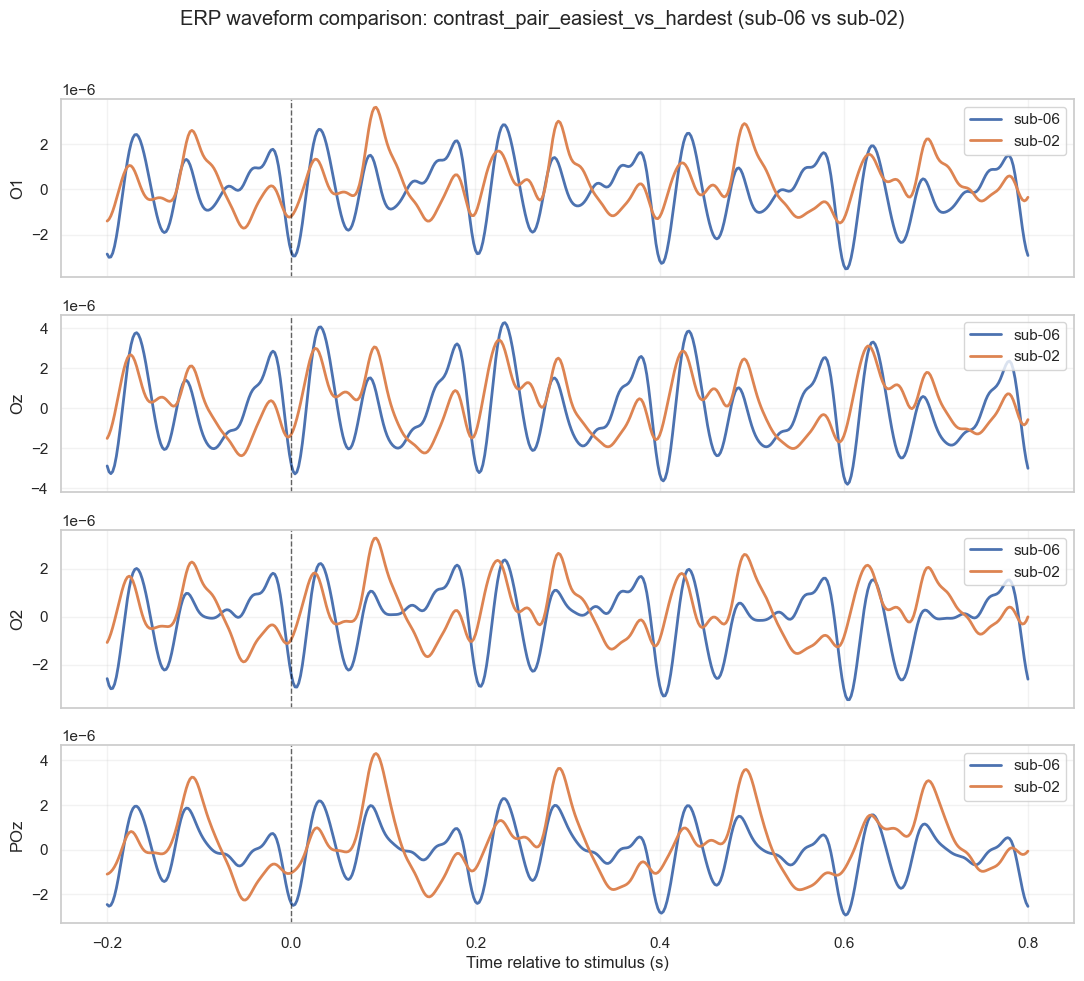

In [6]:
preferred_channels = ["O1", "Oz", "O2", "POz"]

for pair_name, (a, b, erp_a, erp_b, ch_names) in erp_cache.items():
    t = np.arange(erp_a.shape[1]) / FS - 0.2
    channels_to_plot = [ch for ch in preferred_channels if ch in ch_names]
    if not channels_to_plot:
        channels_to_plot = ch_names[:4]

    fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(11, 2.4 * len(channels_to_plot)), sharex=True)
    if len(channels_to_plot) == 1:
        axes = [axes]

    for ax, ch in zip(axes, channels_to_plot):
        ch_idx = ch_names.index(ch)
        ax.plot(t, erp_a[ch_idx], label=a, linewidth=2)
        ax.plot(t, erp_b[ch_idx], label=b, linewidth=2)
        ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
        ax.set_ylabel(ch)
        ax.legend(loc="upper right")
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Time relative to stimulus (s)")
    fig.suptitle(f"ERP waveform comparison: {pair_name} ({a} vs {b})", y=1.02)
    plt.tight_layout()
    plt.show()

## 3. Reverse Identification Using Random Fragmented Signals

The previous DWT feature matrix uses the whole epoch. Here we deliberately make the task harder:

$$
x_i(t) \rightarrow x_i(t_s:t_s+L), \quad t_s \sim \mathrm{Uniform}(0,T-L)
$$

For each subject, we randomly crop short fragments from raw preprocessed epochs, extract wavelet summary features from the fragment, and train an SVM to identify the subject. This is the "reverse" test suggested in the feedback: given a small broken piece of EEG signal, can the model infer whose signal it is?

Expected interpretation:

- near **10%** means fragments do not carry subject identity;
- clearly above **10%** means local signal pieces still contain biometric structure;
- increasing accuracy with longer fragments supports a time-frequency accumulation explanation.

In [7]:
def coeff_features_vec(c, eps=1e-12):
    energy = np.sum(c * c)
    log_energy = np.log(energy + eps)
    mean = np.mean(c)
    std = np.std(c)
    p = (c * c) / (energy + eps)
    entropy = -np.sum(p * np.log(p + eps))
    return np.array([energy, log_energy, mean, std, entropy], dtype=np.float32)

def fragment_to_dwt_features(fragment, wavelet="db4", level=4):
    feats = []
    for ch in range(fragment.shape[0]):
        max_level = pywt.dwt_max_level(fragment.shape[1], pywt.Wavelet(wavelet).dec_len)
        use_level = max(1, min(level, max_level))
        coeffs = pywt.wavedec(fragment[ch], wavelet, level=use_level)
        for c in coeffs:
            feats.append(coeff_features_vec(c))
    return np.concatenate(feats).astype(np.float32)

def build_random_fragment_dataset(
    base_dir=RAW_8CH_DIR,
    fragment_len=250,
    fragments_per_subject=1500,
    max_source_trials_per_subject=12000,
    wavelet="db4",
    level=4,
    seed=RANDOM_STATE,
):
    rng = np.random.default_rng(seed)
    X_frag, y_frag = [], []
    ch_names_ref = None

    subject_dirs = sorted(glob.glob(os.path.join(base_dir, "sub-*")))[:10]
    for subject_idx, subject_dir in enumerate(subject_dirs):
        path = os.path.join(subject_dir, "preprocessed_eeg_train.npz")
        data_raw = np.load(path, allow_pickle=True)
        epochs = data_raw["preprocessed_eeg_data"]
        ch_names = [str(x) for x in data_raw["ch_names"]]
        if ch_names_ref is None:
            ch_names_ref = ch_names

        if epochs.shape[0] > max_source_trials_per_subject:
            source_idx = rng.choice(epochs.shape[0], size=max_source_trials_per_subject, replace=False)
            epochs = epochs[source_idx]

        n_trials, _, n_times = epochs.shape
        if fragment_len > n_times:
            raise ValueError(f"fragment_len={fragment_len} exceeds n_times={n_times}")

        trial_idx = rng.integers(0, n_trials, size=fragments_per_subject)
        starts = rng.integers(0, n_times - fragment_len + 1, size=fragments_per_subject)

        for tr, st in zip(trial_idx, starts):
            fragment = epochs[tr, :, st:st + fragment_len]
            X_frag.append(fragment_to_dwt_features(fragment, wavelet=wavelet, level=level))
            y_frag.append(subject_idx)

        print(f"{os.path.basename(subject_dir)} done: {fragments_per_subject} fragments")

    return np.vstack(X_frag), np.array(y_frag), ch_names_ref

print("Fragment feature helpers loaded.")

Fragment feature helpers loaded.


In [8]:
# Tune these if runtime is too long on your machine.
FRAGMENT_LENGTHS = [125, 250, 501]  # 0.25s, 0.50s, full 1.00s at 500 Hz
FRAGMENTS_PER_SUBJECT = 1500

fragment_results = []
fragment_predictions = {}

for frag_len in FRAGMENT_LENGTHS:
    print("\n" + "=" * 70)
    print(f"Building fragment dataset for length={frag_len} samples ({frag_len / FS:.2f}s)")
    X_frag, y_frag, frag_ch_names = build_random_fragment_dataset(
        fragment_len=frag_len,
        fragments_per_subject=FRAGMENTS_PER_SUBJECT,
        seed=RANDOM_STATE + frag_len,
    )

    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        X_frag,
        y_frag,
        test_size=0.2,
        stratify=y_frag,
        random_state=RANDOM_STATE,
    )

    svm_rbf = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=3.0, gamma="scale", random_state=RANDOM_STATE),
    )
    svm_linear = make_pipeline(
        StandardScaler(),
        LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE),
    )

    for model_name, model in [("Fragment RBF-SVM", svm_rbf), ("Fragment Linear-SVM", svm_linear)]:
        model.fit(X_train_f, y_train_f)
        y_pred_f = model.predict(X_test_f)
        acc_f = accuracy_score(y_test_f, y_pred_f)
        fragment_results.append({
            "fragment_samples": frag_len,
            "fragment_seconds": frag_len / FS,
            "model": model_name,
            "accuracy": acc_f,
            "chance_level": CHANCE_LEVEL,
            "n_train": len(y_train_f),
            "n_test": len(y_test_f),
            "n_features": X_frag.shape[1],
        })
        fragment_predictions[(frag_len, model_name)] = (y_test_f, y_pred_f)
        print(f"{model_name:<20} | length={frag_len:>3} | accuracy={acc_f:.4f} ({acc_f * 100:.2f}%)")

fragment_results_df = pd.DataFrame(fragment_results)
display(fragment_results_df)


Building fragment dataset for length=125 samples (0.25s)
sub-01 done: 1500 fragments
sub-02 done: 1500 fragments
sub-03 done: 1500 fragments
sub-04 done: 1500 fragments
sub-05 done: 1500 fragments
sub-06 done: 1500 fragments
sub-07 done: 1500 fragments
sub-08 done: 1500 fragments
sub-09 done: 1500 fragments
sub-10 done: 1500 fragments
Fragment RBF-SVM     | length=125 | accuracy=0.5590 (55.90%)
Fragment Linear-SVM  | length=125 | accuracy=0.5700 (57.00%)

Building fragment dataset for length=250 samples (0.50s)
sub-01 done: 1500 fragments
sub-02 done: 1500 fragments
sub-03 done: 1500 fragments
sub-04 done: 1500 fragments
sub-05 done: 1500 fragments
sub-06 done: 1500 fragments
sub-07 done: 1500 fragments
sub-08 done: 1500 fragments
sub-09 done: 1500 fragments
sub-10 done: 1500 fragments
Fragment RBF-SVM     | length=250 | accuracy=0.6757 (67.57%)
Fragment Linear-SVM  | length=250 | accuracy=0.7127 (71.27%)

Building fragment dataset for length=501 samples (1.00s)
sub-01 done: 1500 frag

,fragment_samples,fragment_seconds,model,accuracy,chance_level,n_train,n_test,n_features
0,125,0.250,Fragment RBF-SVM,0.559000,0.1,12000,3000,200
1,125,0.250,Fragment Linear-SVM,0.570000,0.1,12000,3000,200
2,250,0.500,Fragment RBF-SVM,0.675667,0.1,12000,3000,200
3,250,0.500,Fragment Linear-SVM,0.712667,0.1,12000,3000,200
4,501,1.002,Fragment RBF-SVM,0.815333,0.1,12000,3000,200
5,501,1.002,Fragment Linear-SVM,0.857667,0.1,12000,3000,200


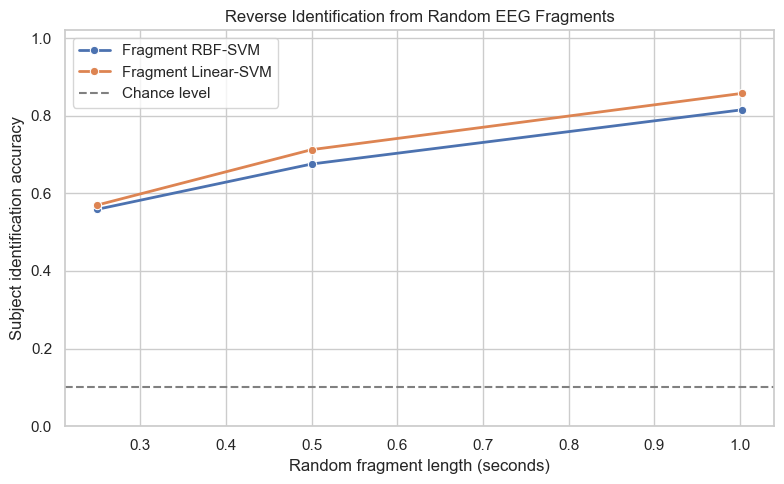

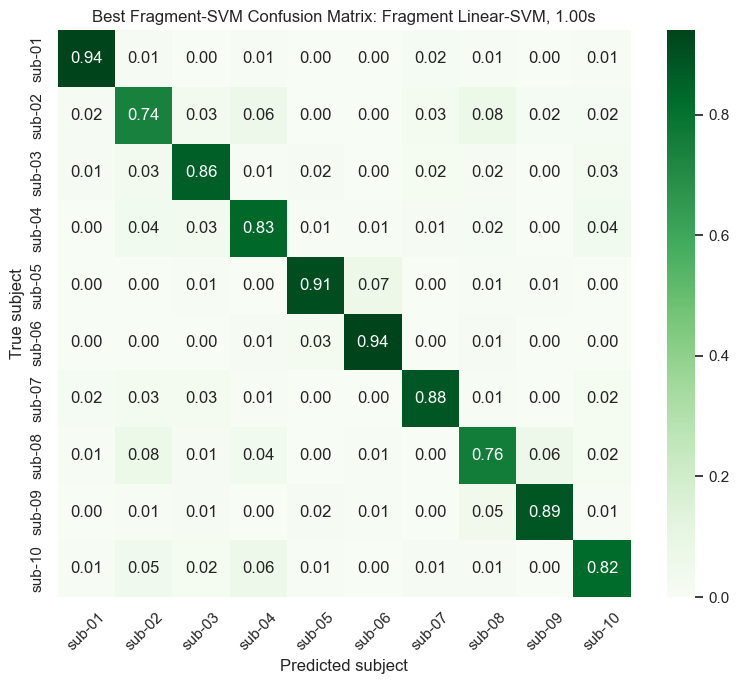

In [9]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=fragment_results_df,
    x="fragment_seconds",
    y="accuracy",
    hue="model",
    marker="o",
    linewidth=2,
)
plt.axhline(CHANCE_LEVEL, color="gray", linestyle="--", label="Chance level")
plt.ylim(0, 1.02)
plt.xlabel("Random fragment length (seconds)")
plt.ylabel("Subject identification accuracy")
plt.title("Reverse Identification from Random EEG Fragments")
plt.legend()
plt.tight_layout()
plt.show()

best_row = fragment_results_df.sort_values("accuracy", ascending=False).iloc[0]
best_key = (int(best_row["fragment_samples"]), best_row["model"])
y_test_best, y_pred_best = fragment_predictions[best_key]

cm_frag = confusion_matrix(y_test_best, y_pred_best, normalize="true")
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_frag,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=SUBJECT_LABELS,
    yticklabels=SUBJECT_LABELS,
)
plt.xlabel("Predicted subject")
plt.ylabel("True subject")
plt.title(f"Best Fragment-SVM Confusion Matrix: {best_row['model']}, {best_row['fragment_seconds']:.2f}s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Permutation Control for Fragment-SVM

The test shuffles labels after fragment extraction. A valid biometric signal should produce high accuracy only with true labels, while shuffled labels should collapse near chance.

In [12]:
RUN_FRAGMENT_PERMUTATION = True
N_PERMUTATIONS = 20

if RUN_FRAGMENT_PERMUTATION:
    frag_len = int(best_row["fragment_samples"])
    print(f"Running permutation control at fragment length={frag_len} samples")
    X_perm, y_perm_true, _ = build_random_fragment_dataset(
        fragment_len=frag_len,
        fragments_per_subject=FRAGMENTS_PER_SUBJECT,
        seed=RANDOM_STATE + 999,
    )

    rng = np.random.default_rng(RANDOM_STATE)
    perm_scores = []
    for i in range(N_PERMUTATIONS):
        y_perm = rng.permutation(y_perm_true)
        X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
            X_perm,
            y_perm,
            test_size=0.2,
            stratify=y_perm,
            random_state=RANDOM_STATE,
        )
        model = make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", C=3.0, gamma="scale", random_state=RANDOM_STATE),
        )
        model.fit(X_train_p, y_train_p)
        score = model.score(X_test_p, y_test_p)
        perm_scores.append(score)
        print(f"Permutation {i + 1:02d}: {score:.4f}")

    print("Permutation mean:", np.mean(perm_scores))
    print("Permutation std:", np.std(perm_scores))
    print("Chance level:", CHANCE_LEVEL)
else:
    print("Permutation control skipped. Set RUN_FRAGMENT_PERMUTATION=True to run it.")

Running permutation control at fragment length=501 samples
sub-01 done: 1500 fragments
sub-02 done: 1500 fragments
sub-03 done: 1500 fragments
sub-04 done: 1500 fragments
sub-05 done: 1500 fragments
sub-06 done: 1500 fragments
sub-07 done: 1500 fragments
sub-08 done: 1500 fragments
sub-09 done: 1500 fragments
sub-10 done: 1500 fragments
Permutation 01: 0.0947
Permutation 02: 0.1017
Permutation 03: 0.1070
Permutation 04: 0.1040
Permutation 05: 0.1027
Permutation 06: 0.1043
Permutation 07: 0.0997
Permutation 08: 0.1050
Permutation 09: 0.0983
Permutation 10: 0.1033
Permutation 11: 0.0930
Permutation 12: 0.1040
Permutation 13: 0.1043
Permutation 14: 0.0997
Permutation 15: 0.1053
Permutation 16: 0.0990
Permutation 17: 0.0967
Permutation 18: 0.0980
Permutation 19: 0.1007
Permutation 20: 0.1030
Permutation mean: 0.10121666666666669
Permutation std: 0.003670112017666793
Chance level: 0.1
